In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
from confit.metrics.correlation import spearman
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
summary = pd.read_csv("performance_summary_spearman_fixed.csv", index_col=0)

In [4]:
summary

,dataset,shot,a_type,a_init,combined_way,train_mode,spearman,zeroshot_sr,num_mutations
0,GDIA_HUMAN_Silverstein_2021,96,position-specific,-1.0,logits,full,0.482953,0.496445,234
1,GDIA_HUMAN_Silverstein_2021,96,context-specific,-1.0,scores,a,0.441523,0.496445,234
2,GDIA_HUMAN_Silverstein_2021,96,context-specific,0.1,logits,full,0.449594,0.496445,234
3,GDIA_HUMAN_Silverstein_2021,96,single,0.1,logits,full,0.460010,0.496445,234
4,GDIA_HUMAN_Silverstein_2021,96,none,0.1,scores,full,0.462524,0.496445,234
...,...,...,...,...,...,...,...,...,...
2891,HXK4_HUMAN_Gersing_2022_activity,96,position-specific,0.1,logits,a,0.461602,0.499336,1716
2892,HXK4_HUMAN_Gersing_2022_activity,96,single,-1.0,logits,a,0.484998,0.499336,1716
2893,HXK4_HUMAN_Gersing_2022_activity,96,context-specific,-1.0,scores,full,0.462386,0.499336,1716
2894,HXK4_HUMAN_Gersing_2022_activity,96,position-specific,-1.0,logits,a,0.485051,0.499336,1716


In [5]:
summary.describe()

,shot,a_init,spearman,zeroshot_sr,num_mutations
count,2896.0,2896.000000,2896.000000,2871.000000,2896.000000
mean,96.0,-0.427590,0.485725,0.432367,945.261050
std,0.0,0.549638,0.167897,0.184334,829.053775
min,96.0,-1.000000,-0.093170,-0.064227,36.000000
25%,96.0,-1.000000,0.380754,0.331102,318.000000
50%,96.0,0.100000,0.517441,0.459064,672.000000
75%,96.0,0.100000,0.607260,0.566665,1398.000000
max,96.0,0.100000,0.808056,0.735572,3384.000000


In [11]:
summary['spearman_abs'] = summary['spearman'].abs()
summary_sorted = summary.sort_values(['dataset', 'spearman_abs'], ascending=[True, False])
best_per_dataset = summary_sorted.groupby('dataset').first().reset_index()

In [9]:
mask = (
    (summary["a_type"]       == "position-specific") &
    (summary["a_init"]       == -1.0) &
    (summary["combined_way"] == "logits") &
    (summary["train_mode"]   == "full")
)
ds_spearman = summary.loc[mask, ["dataset", "shot", "spearman"]].reset_index(drop=True)

In [10]:
ds_spearman

,dataset,shot,spearman
0,GDIA_HUMAN_Silverstein_2021,96,0.482953
1,R1AB_SARS2_Flynn_2022,96,0.391500
2,NRAM_I33A0_Jiang_2016,96,0.339150
3,BLAT_ECOLX_Jacquier_2013,96,0.770790
4,A0A192B1T2_9HIV1_Haddox_2018,96,0.612028
...,...,...,...
111,ANCSZ_Hobbs_2022,96,0.598184
112,B2L11_HUMAN_Dutta_2010_binding-Mcl-1,96,0.800206
113,HXK4_HUMAN_Gersing_2023_abundance,96,0.380684
114,AACC1_PSEAI_Dandage_2018,96,0.572623


In [12]:
best_per_dataset.describe()

,shot,a_init,spearman,zeroshot_sr,num_mutations,spearman_abs
count,116.0,116.000000,116.000000,115.000000,116.000000,116.000000
mean,96.0,-0.706034,0.516996,0.432484,944.379310,0.516996
std,0.0,0.488883,0.154652,0.185006,832.273614,0.154652
min,96.0,-1.000000,0.093634,-0.064227,36.000000,0.093634
25%,96.0,-1.000000,0.410962,0.335531,315.000000,0.410962
50%,96.0,-1.000000,0.542119,0.459064,654.000000,0.542119
75%,96.0,0.100000,0.620503,0.563039,1389.000000,0.620503
max,96.0,0.100000,0.808056,0.735572,3384.000000,0.808056


In [14]:
deep_seq = pd.read_excel("SPURS_SourceData.xlsx", sheet_name="fig4cd")

In [15]:
best_with_deepseq = ds_spearman.copy().merge(deep_seq, left_on="dataset", right_on="protein", how="left")

In [16]:
best_with_dseq = best_with_deepseq[~best_with_deepseq["protein"].isna()][["dataset", "spearman", "SPURS-augmented model", "augmented model"]]

In [17]:
zs_map = summary.copy().drop_duplicates("dataset").set_index("dataset")["zeroshot_sr"]
best_with_dseq["zeroshot_sr"] = best_with_dseq["dataset"].map(zs_map)

In [18]:
best_with_dseq

,dataset,spearman,SPURS-augmented model,augmented model,zeroshot_sr
0,GDIA_HUMAN_Silverstein_2021,0.482953,0.4465,0.4314,0.496445
1,R1AB_SARS2_Flynn_2022,0.391500,0.5886,0.3587,-0.062248
2,NRAM_I33A0_Jiang_2016,0.339150,0.7103,0.6360,0.427396
3,BLAT_ECOLX_Jacquier_2013,0.770790,0.7543,0.7135,0.735572
4,A0A192B1T2_9HIV1_Haddox_2018,0.612028,0.5597,0.4635,0.520518
...,...,...,...,...,...
111,ANCSZ_Hobbs_2022,0.598184,0.5442,0.5077,0.523535
112,B2L11_HUMAN_Dutta_2010_binding-Mcl-1,0.800206,0.7623,0.7812,0.124614
113,HXK4_HUMAN_Gersing_2023_abundance,0.380684,0.4601,0.3713,0.343545
114,AACC1_PSEAI_Dandage_2018,0.572623,0.4892,0.4654,0.522289


In [19]:
from scipy.stats import wilcoxon

# ── aliases ───────────────────────────────────────────────────────────────
psi = best_with_dseq["spearman"]
esm = best_with_dseq["zeroshot_sr"]
aug = best_with_dseq["augmented model"]
n   = len(best_with_dseq)

# ── 1. Paired Wilcoxon ───────────────────────────────────────────────────
s1, p1 = wilcoxon(psi, esm)
s2, p2 = wilcoxon(psi, aug)
print("=== 1. Wilcoxon signed-rank ===")
print(f"PsiFit vs ESM-1v    :  stat={s1:.0f},  p={p1:.4f}  {'*' if p1<0.05 else 'n.s.'}")
print(f"PsiFit vs AugDeepSeq:  stat={s2:.0f},  p={p2:.4e}  {'*' if p2<0.05 else 'n.s.'}")

# ── 2. Overall mean & median ─────────────────────────────────────────────
print(f"\n=== 2. Overall Spearman (n={n}) ===")
for label, s in [("PsiFit", psi), ("ESM-1v", esm), ("AugDeepSeq", aug)]:
    print(f"  {label:<12}  mean={s.mean():.4f}  median={s.median():.4f}")

# ── 3. Win counts ────────────────────────────────────────────────────────
print("\n=== 3. PsiFit win rate ===")
for label, s in [("ESM-1v", esm), ("AugDeepSeq", aug)]:
    wins = (psi > s).sum()
    print(f"  PsiFit > {label:<12}:  {wins}/{n} = {wins/n*100:.1f}%")

# ── 4. Per-category breakdown ────────────────────────────────────────────
meta_cat = (
    pd.read_csv("data/fitness/DMS_substitutions.csv",
                usecols=["DMS_id", "coarse_selection_type"])
      .drop_duplicates("DMS_id")
      .rename(columns={"DMS_id": "dataset"})
)
df_cat = best_with_dseq.merge(meta_cat, on="dataset", how="left")

def _cat_row(g):
    ps, es, au = g["spearman"], g["SPURS-augmented model"], g["augmented model"]
    return pd.Series({
        "n":          len(g),
        "psi_mean":   round(ps.mean(), 3),
        "psi_med":    round(ps.median(), 3),
        "esm_mean":   round(es.mean(), 3),
        "esm_med":    round(es.median(), 3),
        "aug_mean":   round(au.mean(), 3),
        "aug_med":    round(au.median(), 3),
        "win_esm%":   round((ps > es).mean() * 100, 1),
        "win_aug%":   round((ps > au).mean() * 100, 1),
    })

print("\n=== 4. Per-category ===")
print(df_cat.groupby("coarse_selection_type", observed=True)
            .apply(_cat_row, include_groups=False)
            .to_string())

# ── 5. Relative improvement (PsiFit - ESM) / ESM × 100 ──────────────────
rel = (psi - esm) / esm * 100
q   = rel.quantile([0, 0.25, 0.50, 0.75, 1.0])
print("\n=== 5. Relative improvement vs ESM-1v ===")
print(f"  median      : {rel.median():.2f}%")
print(f"  % positive  : {(rel > 0).mean()*100:.1f}%")
print(f"  min/25/50/75/max: "
      f"{q[0]:.1f}% / {q[0.25]:.1f}% / {q[0.50]:.1f}% / {q[0.75]:.1f}% / {q[1.0]:.1f}%")


=== 1. Wilcoxon signed-rank ===
PsiFit vs ESM-1v    :  stat=1031,  p=0.0000  *
PsiFit vs AugDeepSeq:  stat=1781,  p=2.3245e-05  *

=== 2. Overall Spearman (n=114) ===
  PsiFit        mean=0.5090  median=0.5273
  ESM-1v        mean=0.4331  median=0.4609
  AugDeepSeq    mean=0.4792  median=0.4900

=== 3. PsiFit win rate ===
  PsiFit > ESM-1v      :  84/114 = 73.7%
  PsiFit > AugDeepSeq  :  79/114 = 69.3%

=== 4. Per-category ===
                          n  psi_mean  psi_med  esm_mean  esm_med  aug_mean  aug_med  win_esm%  win_aug%
coarse_selection_type                                                                                   
Activity               33.0     0.516    0.538     0.535    0.560     0.501    0.523      48.5      69.7
Binding                 7.0     0.508    0.424     0.519    0.479     0.488    0.427      42.9      57.1
Expression             15.0     0.575    0.630     0.565    0.595     0.471    0.467      46.7     100.0
OrganismalFitness      59.0     0.488    0.5

In [8]:
# Rebuild best_with_dseq with coarse_type and viral flag for new analyses
bwd = best_with_deepseq[~best_with_deepseq["protein"].isna()].copy()
bwd = bwd.rename(columns={
    "spearman":              "confit",
    "SPURS-augmented model": "spurs_ridge",
    "augmented model":       "ridge_base",
})
bwd["delta_spurs"] = bwd["confit"] - bwd["spurs_ridge"]
bwd["delta_ridge"]  = bwd["confit"] - bwd["ridge_base"]

viral_kw = ["INFA","I34A1","I33A0","SARS","HIV","DEN2","RDRP","NCAP","NRAM","PA_"]
bwd["is_viral"] = bwd["dataset"].apply(lambda d: any(k in d for k in viral_kw))

# attach zero-shot from summary
zs_map = summary.drop_duplicates("dataset").set_index("dataset")["zeroshot_sr"]
bwd["zeroshot"] = bwd["dataset"].map(zs_map)
bwd["confit_gain"] = bwd["confit"]  - bwd["zeroshot"]
bwd["spurs_gain"]  = bwd["spurs_ridge"] - bwd["zeroshot"]

print(f"Total matched: {len(bwd)}  |  viral: {bwd['is_viral'].sum()}  |  non-viral: {(~bwd['is_viral']).sum()}")
bwd[["dataset","confit","spurs_ridge","ridge_base","coarse_type","is_viral"]].head()


Total matched: 114  |  viral: 13  |  non-viral: 101


,dataset,confit,spurs_ridge,ridge_base,coarse_type,is_viral
1,A0A192B1T2_9HIV1_Haddox_2018,0.614255,0.5597,0.4635,OrganismalFitness,True
2,A0A1I9GEU1_NEIME_Kennouche_2019,0.093634,0.0676,0.0702,Activity,False
3,A0A247D711_LISMN_Stadelmann_2021,0.417380,0.5255,0.3451,Activity,False
4,A0A2Z5U3Z0_9INFA_Doud_2016,0.611614,0.6472,0.5326,OrganismalFitness,True
5,A0A2Z5U3Z0_9INFA_Wu_2014,0.480403,0.5010,0.4557,OrganismalFitness,True


In [9]:
from scipy.stats import wilcoxon

stat1, p1 = wilcoxon(bwd["confit"], bwd["spurs_ridge"])
stat2, p2 = wilcoxon(bwd["confit"], bwd["ridge_base"])

print(f"Wilcoxon — ConFit vs SPURS-Ridge:  stat={stat1:.0f},  p={p1:.4f}  {'n.s.' if p1>0.05 else '*'}")
print(f"Wilcoxon — ConFit vs Ridge (base): stat={stat2:.0f},  p={p2:.2e}  {'n.s.' if p2>0.05 else '***'}")
print()
print("Win rates (all 114 datasets):")
print(f"  ConFit > SPURS-Ridge : {(bwd.confit > bwd.spurs_ridge).sum()}/114 = {(bwd.confit > bwd.spurs_ridge).mean()*100:.1f}%")
print(f"  ConFit > Ridge-base  : {(bwd.confit > bwd.ridge_base).sum()}/114 = {(bwd.confit > bwd.ridge_base).mean()*100:.1f}%")
print(f"  SPURS-Ridge > Ridge  : {(bwd.spurs_ridge > bwd.ridge_base).sum()}/114 = {(bwd.spurs_ridge > bwd.ridge_base).mean()*100:.1f}%")


Wilcoxon — ConFit vs SPURS-Ridge:  stat=3142,  p=0.7016  n.s.
Wilcoxon — ConFit vs Ridge (base): stat=1337,  p=4.10e-08  ***

Win rates (all 114 datasets):
  ConFit > SPURS-Ridge : 57/114 = 50.0%
  ConFit > Ridge-base  : 86/114 = 75.4%
  SPURS-Ridge > Ridge  : 90/114 = 78.9%


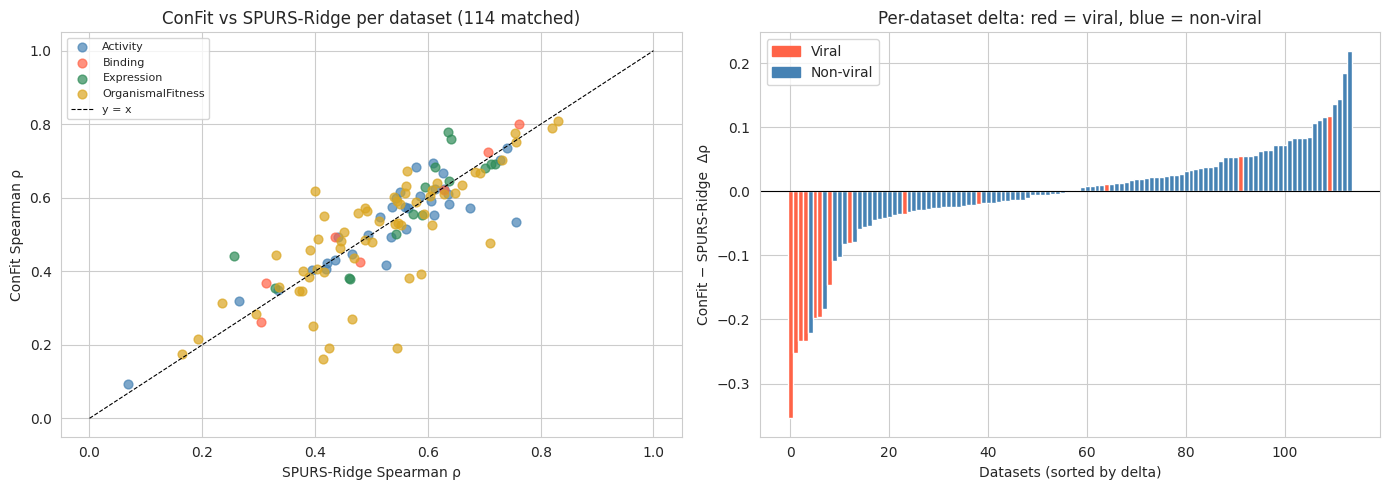

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {"Activity":"steelblue","Binding":"tomato","Expression":"seagreen","OrganismalFitness":"goldenrod"}

# Left: scatter per coarse_type
for ctype, grp in bwd.groupby("coarse_type"):
    axes[0].scatter(grp["spurs_ridge"], grp["confit"],
                    label=ctype, alpha=0.7, s=40,
                    color=palette.get(ctype, "gray"))
lim = [0, 1]
axes[0].plot(lim, lim, "k--", lw=0.8, label="y = x")
axes[0].set_xlabel("SPURS-Ridge Spearman ρ")
axes[0].set_ylabel("ConFit Spearman ρ")
axes[0].set_title("ConFit vs SPURS-Ridge per dataset (114 matched)")
axes[0].legend(fontsize=8)

# Right: delta (ConFit - SPURS-Ridge) histogram coloured by viral / non-viral
colors = bwd["is_viral"].map({True: "tomato", False: "steelblue"})
axes[1].bar(range(len(bwd)),
            bwd.sort_values("delta_spurs")["delta_spurs"].values,
            color=bwd.sort_values("delta_spurs")["is_viral"]
                     .map({True:"tomato",False:"steelblue"}).values,
            width=1.0)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("Datasets (sorted by delta)")
axes[1].set_ylabel("ConFit − SPURS-Ridge  Δρ")
axes[1].set_title("Per-dataset delta: red = viral, blue = non-viral")
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color="tomato",label="Viral"),
                         Patch(color="steelblue",label="Non-viral")])
plt.tight_layout()


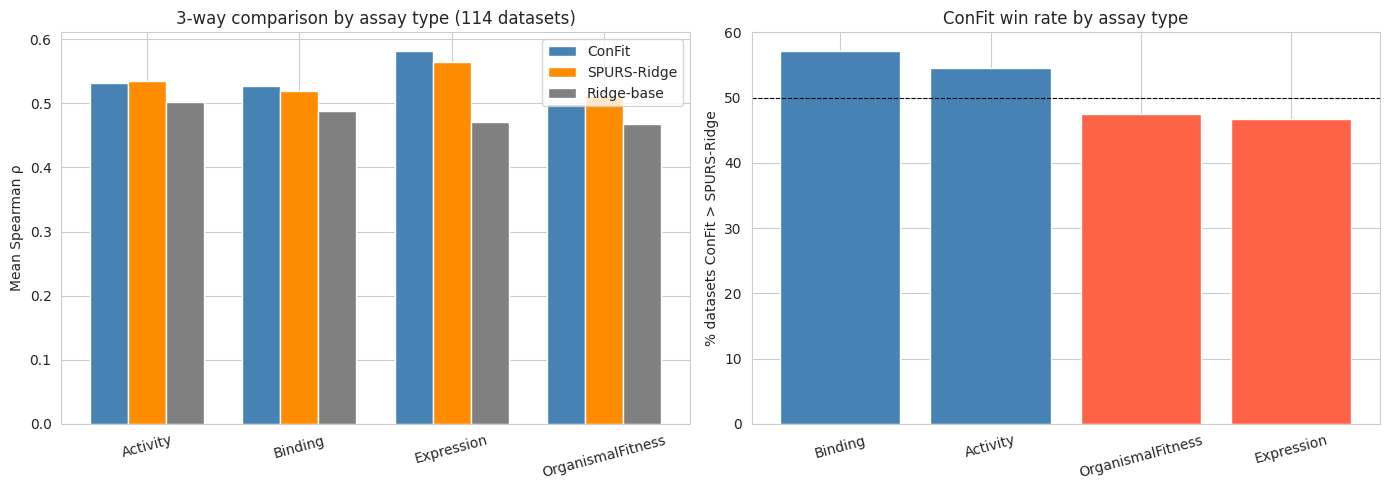

In [11]:
ct_mean = bwd.groupby("coarse_type")[["confit","spurs_ridge","ridge_base"]].mean()
ct_win  = bwd.groupby("coarse_type").apply(
    lambda g: (g["confit"] > g["spurs_ridge"]).mean() * 100,
    include_groups=False
).rename("confit_win_pct")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(ct_mean))
w = 0.25
axes[0].bar(x - w, ct_mean["confit"],      w, label="ConFit",      color="steelblue")
axes[0].bar(x,     ct_mean["spurs_ridge"], w, label="SPURS-Ridge", color="darkorange")
axes[0].bar(x + w, ct_mean["ridge_base"],  w, label="Ridge-base",  color="gray")
axes[0].set_xticks(x)
axes[0].set_xticklabels(ct_mean.index, rotation=15)
axes[0].set_ylabel("Mean Spearman ρ")
axes[0].set_title("3-way comparison by assay type (114 datasets)")
axes[0].legend()

# Right: ConFit win rate vs SPURS-Ridge per coarse_type
ct_win_sorted = ct_win.sort_values(ascending=False)
bar_colors = ["steelblue" if v >= 50 else "tomato" for v in ct_win_sorted]
axes[1].bar(ct_win_sorted.index, ct_win_sorted.values, color=bar_colors)
axes[1].axhline(50, color="black", linestyle="--", lw=0.8)
axes[1].set_ylabel("% datasets ConFit > SPURS-Ridge")
axes[1].set_title("ConFit win rate by assay type")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()


In [12]:
print("=== Viral vs non-viral split ===")
vir = (bwd.groupby("is_viral")
          .agg(n=("dataset","count"),
               confit_mean=("confit","mean"),
               spurs_mean=("spurs_ridge","mean"),
               delta_mean=("delta_spurs","mean"),
               delta_median=("delta_spurs","median"),
               confit_win_pct=("delta_spurs", lambda x: (x>0).mean()*100))
          .round(4))
vir.index = ["Non-viral","Viral"]
print(vir.to_string())
print()

# non-viral only significance
nv = bwd[~bwd["is_viral"]]
from scipy.stats import wilcoxon
stat_nv, p_nv = wilcoxon(nv["confit"], nv["spurs_ridge"])
print(f"Wilcoxon (non-viral only): stat={stat_nv:.0f}, p={p_nv:.4f}  {'*' if p_nv<0.05 else 'n.s.'}")
print(f"Non-viral: ConFit wins {(nv.confit>nv.spurs_ridge).sum()}/{len(nv)} = {(nv.confit>nv.spurs_ridge).mean()*100:.1f}%")


=== Viral vs non-viral split ===
             n  confit_mean  spurs_mean  delta_mean  delta_median  confit_win_pct
Non-viral  101       0.5335      0.5230      0.0105        0.0074         53.4653
Viral       13       0.4240      0.5446     -0.1205       -0.1458         23.0769

Wilcoxon (non-viral only): stat=2086, p=0.0973  n.s.
Non-viral: ConFit wins 54/101 = 53.5%


=== Gain over zero-shot ESM1v (matched 114 datasets) ===
        confit_gain  spurs_gain
mean         0.0879      0.0924
median       0.0501      0.0392



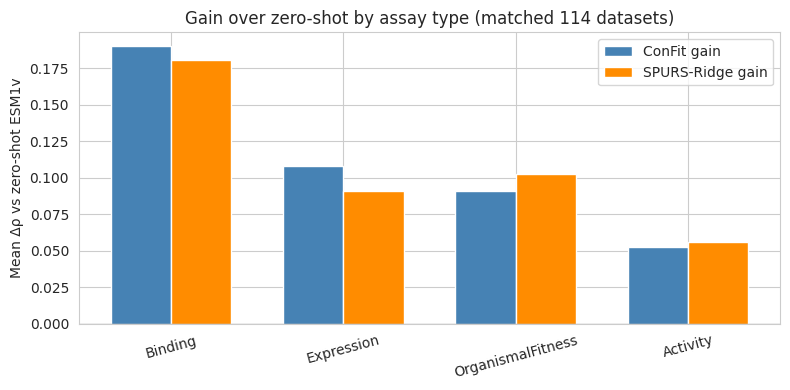

In [13]:
print("=== Gain over zero-shot ESM1v (matched 114 datasets) ===")
gain_df = bwd[["coarse_type","confit_gain","spurs_gain"]].copy()
print(gain_df[["confit_gain","spurs_gain"]].agg(["mean","median"]).round(4))
print()

fig, ax = plt.subplots(figsize=(8, 4))
ct_gain = (gain_df.groupby("coarse_type")[["confit_gain","spurs_gain"]].mean()
                  .sort_values("confit_gain", ascending=False))
x = np.arange(len(ct_gain))
w = 0.35
ax.bar(x - w/2, ct_gain["confit_gain"],  w, label="ConFit gain",      color="steelblue")
ax.bar(x + w/2, ct_gain["spurs_gain"],   w, label="SPURS-Ridge gain", color="darkorange")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(ct_gain.index, rotation=15)
ax.set_ylabel("Mean Δρ vs zero-shot ESM1v")
ax.set_title("Gain over zero-shot by assay type (matched 114 datasets)")
ax.legend()
plt.tight_layout()


In [14]:
print("=== Best a_type frequency per coarse_type ===")
ct_atype = (bwd.groupby(["coarse_type","a_type"]).size()
               .unstack(fill_value=0))
ct_atype["total"] = ct_atype.sum(axis=1)
print(ct_atype)
print()

# mean delta by a_type
print("=== Mean delta (ConFit - SPURS-Ridge) by a_type ===")
print(bwd.groupby("a_type")["delta_spurs"]
        .agg(n="count", mean="mean", median="median").round(4))


=== Best a_type frequency per coarse_type ===
a_type             context-specific  none  position-specific  single  total
coarse_type                                                                
Activity                          6     4                 11      12     33
Binding                           1     1                  4       1      7
Expression                        3     0                  8       4     15
OrganismalFitness                 9     2                 31      17     59

=== Mean delta (ConFit - SPURS-Ridge) by a_type ===
                    n    mean  median
a_type                               
context-specific   19  0.0024 -0.0157
none                7  0.0304  0.0477
position-specific  54 -0.0044  0.0105
single             34 -0.0155 -0.0020


In [15]:
fitness_dir = Path("data/fitness")

folder_map = {
    48:  "results48",
    96:  "results96",
    144: "results144",
    192: "results192",
    240: "results_proteingym",
}

rows = []
for n_train, folder in folder_map.items():
    for csv_path in (fitness_dir / folder).rglob("results.csv"):
        df = pd.read_csv(csv_path)
        rows.append(df)

ridge_df = pd.concat(rows, ignore_index=True)

# vae+onehot+ddg is the SPURS-augmented one (equivalent to SpursRidgeBaseline)
ridge_spurs = ridge_df[ridge_df["predictor"] == "vae+onehot+ddg"]
ridge_base  = ridge_df[ridge_df["predictor"] == "vae+onehot"]

print(ridge_spurs.groupby("n_train")["spearman"].mean().round(4))


n_train
48     0.5007
96     0.5291
144    0.5508
192    0.5666
240    0.5779
Name: spearman, dtype: float64


In [16]:
# Load pre-computed Ridge baseline results (all N values)
fitness_dir = Path("data/fitness")

folder_map = {
    48:  "results48",
    96:  "results96",
    144: "results144",
    192: "results192",
    240: "results_proteingym",
}

rows = []
for n_train, folder in folder_map.items():
    for csv_path in (fitness_dir / folder).rglob("results.csv"):
        df = pd.read_csv(csv_path)
        rows.append(df)

ridge_df = pd.concat(rows, ignore_index=True)

ridge_spurs = ridge_df[ridge_df["predictor"] == "vae+onehot+ddg"]  # SPURS-augmented
ridge_base  = ridge_df[ridge_df["predictor"] == "vae+onehot"]       # no DDG

print(f"Loaded {len(ridge_spurs)} rows for SPURS-augmented Ridge")
print(ridge_spurs.groupby("n_train")["spearman"].mean().round(4))


Loaded 13840 rows for SPURS-augmented Ridge
n_train
48     0.5007
96     0.5291
144    0.5508
192    0.5666
240    0.5779
Name: spearman, dtype: float64


In [17]:
# Clean ablation table
rows = []

# Zero-shot baseline
zs = summary.drop_duplicates("dataset").set_index("dataset")["zeroshot_sr"]
rows.append({
    "method":       "Zero-shot ESM1v",
    "mean_SR":      zs.mean(),
    "median_SR":    zs.median(),
    "pct_beats_zs": "-",
    "mean_gain":    0.0,
})

# Ridge baseline at N=96 (from pre-computed results)
r96_spurs = ridge_spurs[ridge_spurs["n_train"] == 96].groupby("dataset")["spearman"].mean()
r96_base  = ridge_base[ridge_base["n_train"] == 96].groupby("dataset")["spearman"].mean()
for label, r96 in [("Ridge (N=96, no DDG)", r96_base),
                   ("Ridge+SPURS (N=96)",    r96_spurs)]:
    rows.append({
        "method":       label,
        "mean_SR":      r96.mean(),
        "median_SR":    r96.median(),
        "pct_beats_zs": f"{(r96 > zs.reindex(r96.index)).mean()*100:.1f}%",
        "mean_gain":    (r96 - zs.reindex(r96.index)).mean(),
    })

# ConFit ablations (shot=96)
s96 = summary[summary["shot"] == 96].copy()
s96["beats_zs"] = s96["spearman"] > s96["zeroshot_sr"]
s96["gain"]     = s96["spearman"] - s96["zeroshot_sr"]

for a_type in ["none", "single", "position-specific", "context-specific"]:
    sub = s96[s96["a_type"] == a_type]
    rows.append({
        "method":       f"ConFit  a_type={a_type}",
        "mean_SR":      sub["spearman"].mean(),
        "median_SR":    sub["spearman"].median(),
        "pct_beats_zs": f"{sub['beats_zs'].mean()*100:.1f}%",
        "mean_gain":    sub["gain"].mean(),
    })

ablation = pd.DataFrame(rows).round(4)
ablation

,method,mean_SR,median_SR,pct_beats_zs,mean_gain
0,Zero-shot ESM1v,0.4325,0.4591,-,0.0000
1,"Ridge (N=96, no DDG)",0.4763,0.4839,36.9%,0.0460
2,Ridge+SPURS (N=96),0.5291,0.5506,59.6%,0.0924
3,ConFit a_type=none,0.4744,0.5057,51.7%,0.0457
4,ConFit a_type=single,0.4878,0.5227,59.7%,0.0590
5,ConFit a_type=position-specific,0.4877,0.5225,59.5%,0.0589
6,ConFit a_type=context-specific,0.4830,0.5097,58.8%,0.0544


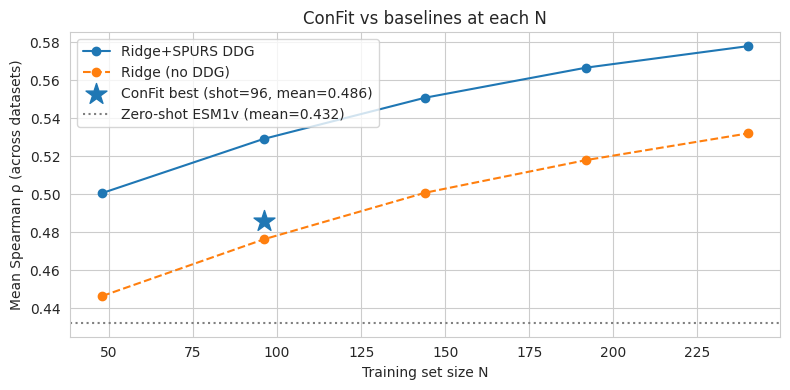

In [18]:
# N comparison plot: Ridge learning curve vs ConFit point
ridge_mean = (ridge_spurs
    .groupby("n_train")["spearman"]
    .mean()
    .reset_index())

ridge_base_mean = (ridge_base
    .groupby("n_train")["spearman"]
    .mean()
    .reset_index())

confit_96 = summary[summary["shot"] == 96]["spearman"].mean()
zs_mean   = summary["zeroshot_sr"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ridge_mean["n_train"],      ridge_mean["spearman"],
        marker="o", label="Ridge+SPURS DDG")
ax.plot(ridge_base_mean["n_train"], ridge_base_mean["spearman"],
        marker="o", linestyle="--", label="Ridge (no DDG)")
ax.scatter([96], [confit_96], marker="*", s=250, zorder=5,
           label=f"ConFit best (shot=96, mean={confit_96:.3f})")
ax.axhline(zs_mean, linestyle=":", color="gray",
           label=f"Zero-shot ESM1v (mean={zs_mean:.3f})")
ax.set_xlabel("Training set size N")
ax.set_ylabel("Mean Spearman ρ (across datasets)")
ax.set_title("ConFit vs baselines at each N")
ax.legend()
plt.tight_layout()


In [19]:
# Load assay type metadata
meta = pd.read_csv("data/fitness/DMS_substitutions.csv",
                   usecols=["DMS_id", "coarse_selection_type",
                             "selection_type", "taxon"])
meta = meta.rename(columns={"DMS_id": "dataset"})

# Merge into summary
summary_meta = summary.merge(meta, on="dataset", how="left")

print(f"Matched: {summary_meta['coarse_selection_type'].notna().sum()} / {len(summary_meta)} rows")
print(summary_meta["coarse_selection_type"].value_counts())


Matched: 2896 / 2896 rows
coarse_selection_type
OrganismalFitness    1496
Activity              825
Expression            375
Binding               175
Stability              25
Name: count, dtype: int64


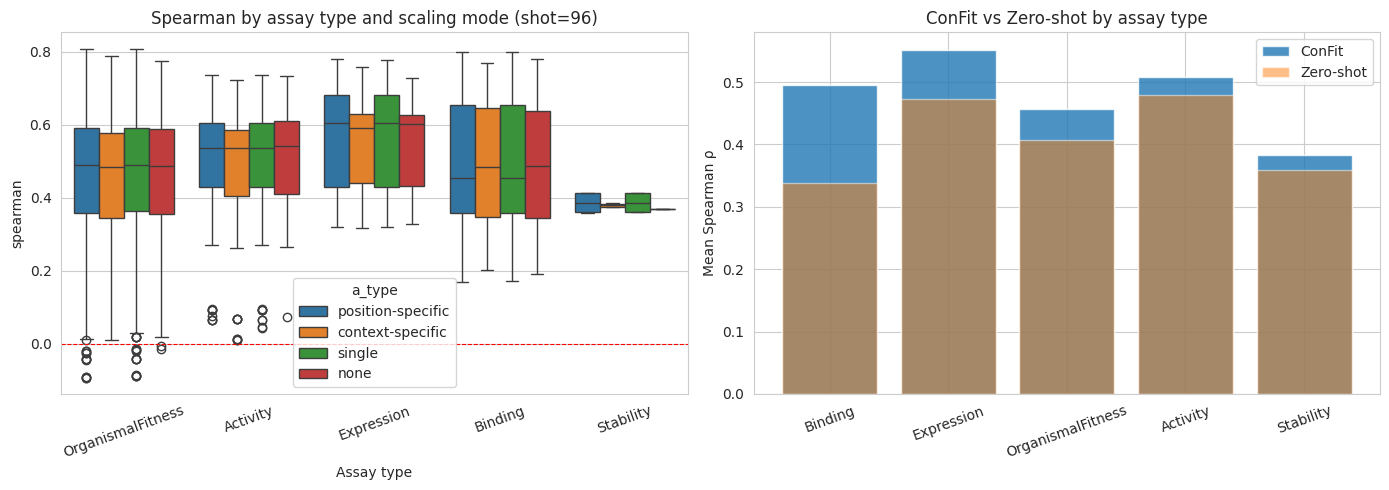

In [20]:
# Stratification by coarse_selection_type — mean Spearman per assay type
s96 = summary_meta[summary_meta["shot"] == 96].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: Spearman distribution per assay type, split by a_type
order = s96["coarse_selection_type"].value_counts().index
sns.boxplot(data=s96, x="coarse_selection_type", y="spearman",
            hue="a_type", order=order, ax=axes[0])
axes[0].axhline(0, linestyle="--", color="red", linewidth=0.8)
axes[0].set_title("Spearman by assay type and scaling mode (shot=96)")
axes[0].set_xlabel("Assay type")
axes[0].tick_params(axis="x", rotation=20)

# Bar chart: mean Spearman vs zero-shot gain per assay type
gain_by_type = (s96.groupby("coarse_selection_type")
                .apply(lambda g: pd.Series({
                    "mean_spearman":  g["spearman"].mean(),
                    "mean_zeroshot":  g["zeroshot_sr"].mean(),
                    "mean_gain":      (g["spearman"] - g["zeroshot_sr"]).mean(),
                    "n_datasets":     g["dataset"].nunique(),
                }))
                .reset_index()
                .sort_values("mean_gain", ascending=False))

x = range(len(gain_by_type))
axes[1].bar(x, gain_by_type["mean_spearman"], label="ConFit", alpha=0.8)
axes[1].bar(x, gain_by_type["mean_zeroshot"], label="Zero-shot", alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(gain_by_type["coarse_selection_type"], rotation=20)
axes[1].set_ylabel("Mean Spearman ρ")
axes[1].set_title("ConFit vs Zero-shot by assay type")
axes[1].legend()

plt.tight_layout()


In [21]:
# Numeric summary table: mean SR, zero-shot SR, gain, n_datasets per assay type
gain_by_type[["coarse_selection_type", "mean_spearman",
              "mean_zeroshot", "mean_gain", "n_datasets"]].round(4)


,coarse_selection_type,mean_spearman,mean_zeroshot,mean_gain,n_datasets
1,Binding,0.4950,0.3378,0.1572,7.0
2,Expression,0.5521,0.4736,0.0785,15.0
3,OrganismalFitness,0.4570,0.4079,0.0556,60.0
0,Activity,0.5088,0.4795,0.0294,33.0
4,Stability,0.3833,0.3590,0.0243,1.0


In [22]:
# Stratification by taxon
taxon_summary = (s96.groupby("taxon")
                 .apply(lambda g: pd.Series({
                     "mean_spearman": g["spearman"].mean(),
                     "mean_zeroshot": g["zeroshot_sr"].mean(),
                     "mean_gain":     (g["spearman"] - g["zeroshot_sr"]).mean(),
                     "n_datasets":    g["dataset"].nunique(),
                 }))
                 .reset_index()
                 .sort_values("mean_gain", ascending=False))
taxon_summary.round(4)


,taxon,mean_spearman,mean_zeroshot,mean_gain,n_datasets
0,Eukaryote,0.5043,0.4045,0.0998,13.0
3,Virus,0.3177,0.2713,0.0609,18.0
1,Human,0.5015,0.4457,0.0558,58.0
2,Prokaryote,0.5553,0.5190,0.0362,27.0


### Test